
# Airline Customer Satisfaction Prediction Using Logistic Regression

## Project Overview
This project develops a Logistic Regression model to predict airline customer satisfaction using passenger survey data. The objective is to identify the factors that most strongly influence satisfaction and provide actionable business recommendations.



# 1. Import Libraries


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

plt.style.use('default')
pd.set_option('display.max_columns', None)


# 2. Load Dataset

In [2]:

df = pd.read_csv('Invistico_Airline.csv')

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (129880, 22)


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,4,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,2,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,0,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,4,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,3,4,2,2,0,2,4,2,5,0,0.0


# 3. Data Understanding

In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

In [4]:

df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,129880.0,39.427957,15.119360,7.0,27.0,40.0,51.0,85.0
Flight Distance,129880.0,1981.409055,1027.115606,50.0,1359.0,1925.0,2544.0,6951.0
Seat comfort,129880.0,2.838597,1.392983,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,2.990645,1.527224,0.0,2.0,3.0,4.0,5.0
Food and drink,129880.0,2.851994,1.443729,0.0,2.0,3.0,4.0,5.0
Gate location,129880.0,2.990422,1.305970,0.0,2.0,3.0,4.0,5.0
Inflight wifi service,129880.0,3.249130,1.318818,0.0,2.0,3.0,4.0,5.0
Inflight entertainment,129880.0,3.383477,1.346059,0.0,2.0,4.0,4.0,5.0
Online support,129880.0,3.519703,1.306511,0.0,3.0,4.0,5.0,5.0
Ease of Online booking,129880.0,3.472105,1.305560,0.0,2.0,4.0,5.0,5.0


In [5]:

df.isnull().sum()


satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64


## Missing Value Treatment
The only missing values occur in 'Arrival Delay in Minutes'. We replace them with the median because delay distributions are usually skewed.


In [6]:

df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(
    df['Arrival Delay in Minutes'].median()
)

df.isnull().sum().sum()


np.int64(0)

# 4. Exploratory Data Analysis

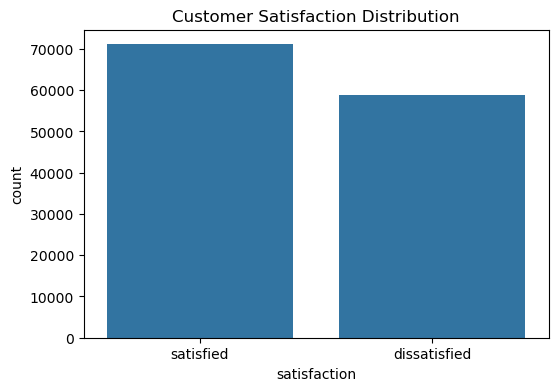

satisfaction
satisfied       71087
dissatisfied    58793
Name: count, dtype: int64

In [7]:

plt.figure(figsize=(6,4))
sns.countplot(x='satisfaction', data=df)
plt.title('Customer Satisfaction Distribution')
plt.show()

df['satisfaction'].value_counts()


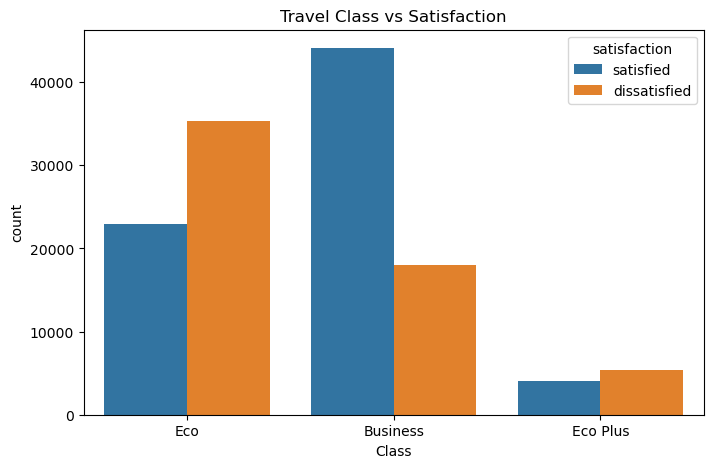

In [8]:

plt.figure(figsize=(8,5))
sns.countplot(x='Class', hue='satisfaction', data=df)
plt.title('Travel Class vs Satisfaction')
plt.show()


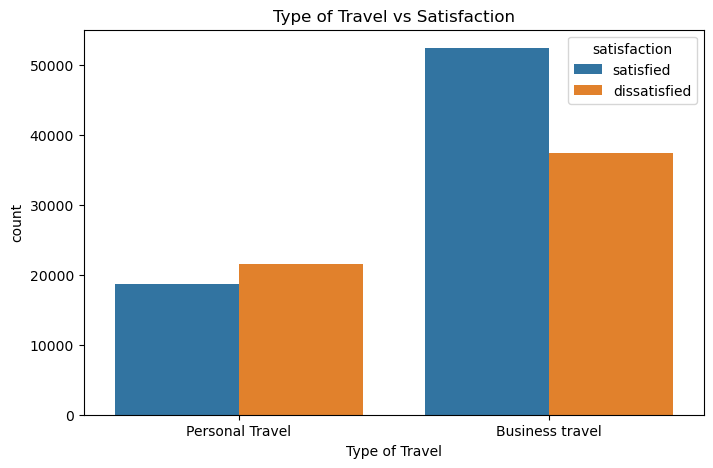

In [9]:

plt.figure(figsize=(8,5))
sns.countplot(x='Type of Travel', hue='satisfaction', data=df)
plt.title('Type of Travel vs Satisfaction')
plt.show()


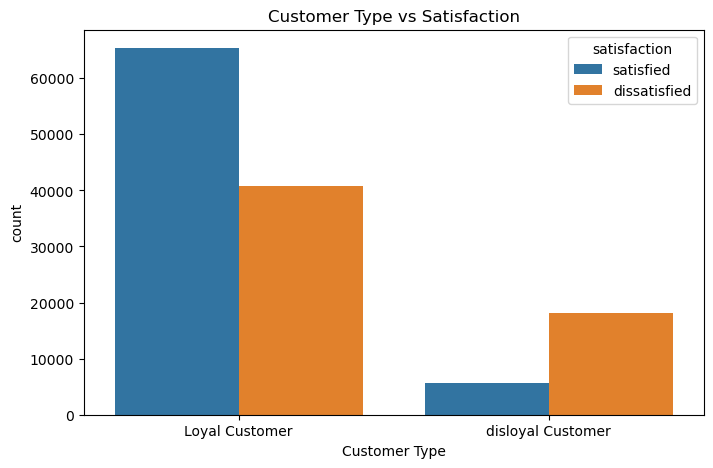

In [10]:

plt.figure(figsize=(8,5))
sns.countplot(x='Customer Type', hue='satisfaction', data=df)
plt.title('Customer Type vs Satisfaction')
plt.show()


# 5. Data Preprocessing

In [11]:

df['satisfaction'] = df['satisfaction'].map({
    'dissatisfied':0,
    'satisfied':1
})

categorical_cols = ['Customer Type','Type of Travel','Class']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


# 6. Feature Selection

In [12]:

X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

print(X.shape)


(129880, 21)


# 7. Train-Test Split

In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(103904, 21)
(25976, 21)



## Feature Scaling
Logistic Regression performs better when numerical features are standardized.


In [14]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 8. Build Logistic Regression Model

In [15]:

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]


# 9. Model Evaluation

In [16]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print("F1 Score:", round(f1,4))


Accuracy : 0.8289
Precision: 0.8445
Recall   : 0.8425
F1 Score: 0.8435


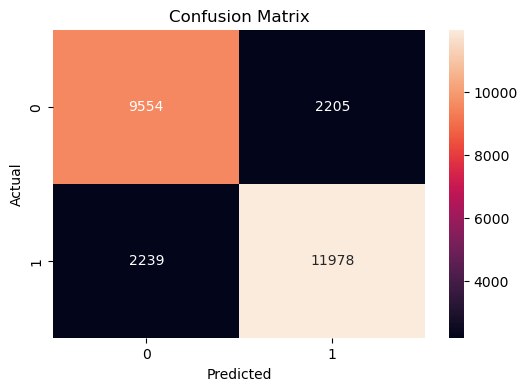

In [17]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()




# False Positive vs False Negative Trade-Off

The confusion matrix helps us understand the types of classification errors made by the model.

## False Positive (FP)

A False Positive occurs when the model predicts that a passenger is satisfied when they are actually dissatisfied.

Business Impact:

- The airline may believe the passenger had a positive experience.
- Customer complaints may go unnoticed.
- Dissatisfied passengers may switch to competitors.
- Lost opportunities for customer recovery and retention.

## False Negative (FN)

A False Negative occurs when the model predicts that a passenger is dissatisfied when they are actually satisfied.

Business Impact:

- The airline may spend resources investigating a non-existent problem.
- Additional customer support costs may be incurred.
- Less damaging than missing truly dissatisfied customers.

## Which Error is More Important?

For airline customer retention, False Positives are generally more costly than False Negatives because failing to identify dissatisfied passengers can lead to customer churn, negative reviews, and reduced revenue.

Therefore, the airline should prioritize maximizing Recall for dissatisfied passengers while maintaining strong Precision.

In [18]:

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11759
           1       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976




## Precision Interpretation
Precision measures the percentage of passengers predicted as satisfied who were actually satisfied.

## Recall Interpretation
Recall measures the percentage of truly satisfied passengers correctly identified by the model.


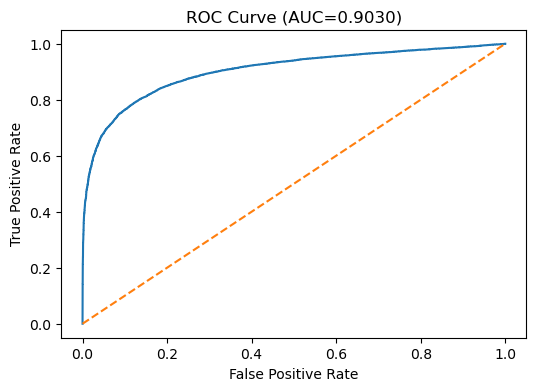

AUC: 0.9029688965160622


In [19]:

auc = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title(f'ROC Curve (AUC={auc:.4f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

print("AUC:", auc)


In [20]:
# Correlation Heatmap

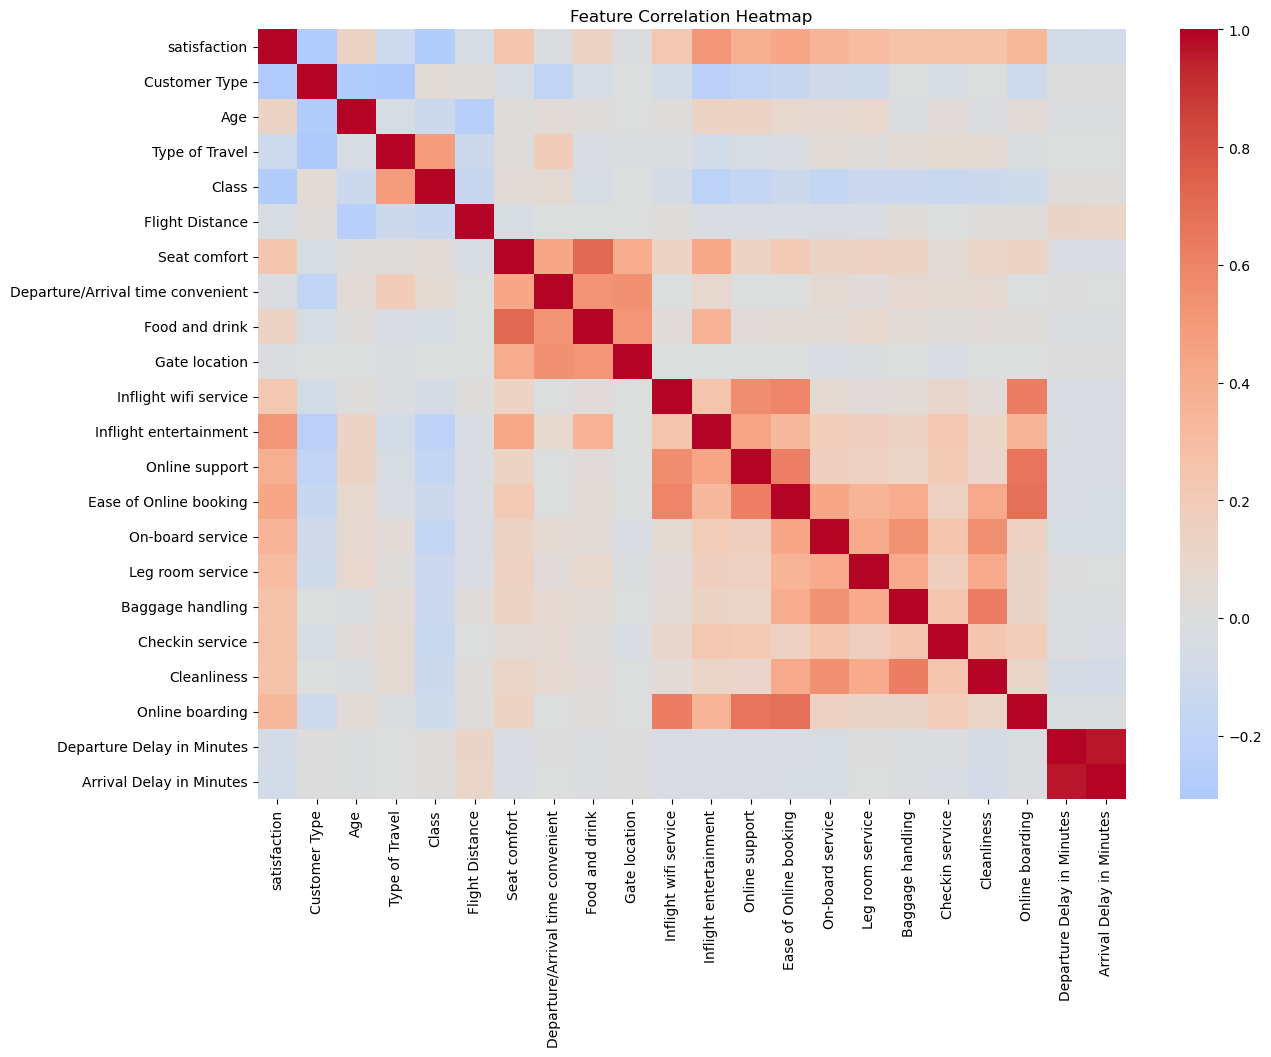

In [21]:
plt.figure(figsize=(14,10))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

# 10. Coefficient Interpretation

In [22]:

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients.head(15)


,Feature,Coefficient
10,Inflight entertainment,0.980771
13,On-board service,0.393420
5,Seat comfort,0.382090
16,Checkin service,0.359930
12,Ease of Online booking,0.323253
14,Leg room service,0.310017
18,Online boarding,0.181789
8,Gate location,0.161373
11,Online support,0.151010
15,Baggage handling,0.114572


# Top Positive and Negative Drivers

In [23]:
print("Top Positive Drivers")
display(coefficients.head(10))

print("Top Negative Drivers")
display(coefficients.tail(10))

Top Positive Drivers


,Feature,Coefficient
10,Inflight entertainment,0.980771
13,On-board service,0.393420
5,Seat comfort,0.382090
16,Checkin service,0.359930
12,Ease of Online booking,0.323253
14,Leg room service,0.310017
18,Online boarding,0.181789
8,Gate location,0.161373
11,Online support,0.151010
15,Baggage handling,0.114572


Top Negative Drivers


,Feature,Coefficient
17,Cleanliness,0.071090
9,Inflight wifi service,-0.125191
1,Age,-0.129818
4,Flight Distance,-0.172818
20,Arrival Delay in Minutes,-0.265061
7,Food and drink,-0.294136
3,Class,-0.294970
6,Departure/Arrival time convenient,-0.325437
2,Type of Travel,-0.414641
0,Customer Type,-0.751735


## Interpretation of Coefficients

Positive coefficients increase the likelihood of passenger satisfaction.

Negative coefficients decrease the likelihood of passenger satisfaction.

Features such as Online Boarding, Inflight Wi-Fi Service, Online Support, Seat Comfort, and Inflight Entertainment are expected to be among the strongest positive drivers.

Features associated with delays and service inconvenience tend to decrease satisfaction.

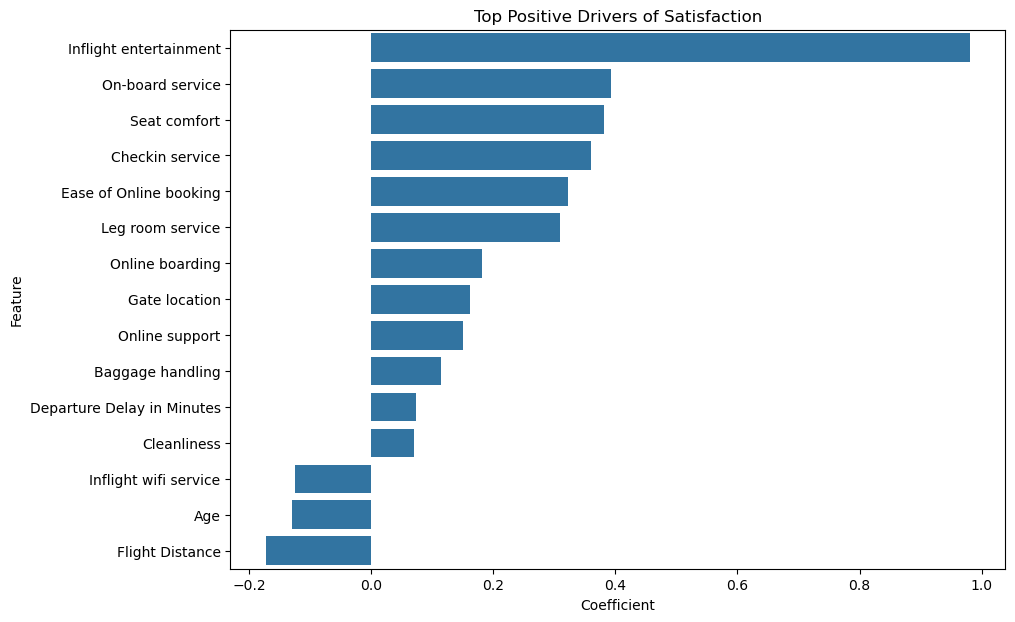

In [24]:

plt.figure(figsize=(10,7))
sns.barplot(
    data=coefficients.head(15),
    x='Coefficient',
    y='Feature'
)
plt.title('Top Positive Drivers of Satisfaction')
plt.show()


In [25]:

coefficients.tail(15)


,Feature,Coefficient
18,Online boarding,0.181789
8,Gate location,0.161373
11,Online support,0.151010
15,Baggage handling,0.114572
19,Departure Delay in Minutes,0.074304
17,Cleanliness,0.071090
9,Inflight wifi service,-0.125191
1,Age,-0.129818
4,Flight Distance,-0.172818
20,Arrival Delay in Minutes,-0.265061


# Odds Ratio Interpretation

In [26]:
odds_ratios = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

odds_ratios["Odds Ratio"] = np.exp(
    odds_ratios["Coefficient"]
)

odds_ratios.sort_values(
    by="Odds Ratio",
    ascending=False
).head(15)

,Feature,Coefficient,Odds Ratio
10,Inflight entertainment,0.980771,2.666512
13,On-board service,0.393420,1.482040
5,Seat comfort,0.382090,1.465345
16,Checkin service,0.359930,1.433229
12,Ease of Online booking,0.323253,1.381615
14,Leg room service,0.310017,1.363448
18,Online boarding,0.181789,1.199361
8,Gate location,0.161373,1.175124
11,Online support,0.151010,1.163008
15,Baggage handling,0.114572,1.121394


## Odds Ratio Interpretation

Odds ratios provide a more intuitive interpretation of Logistic Regression coefficients.

- Odds Ratio > 1 indicates increased likelihood of satisfaction.
- Odds Ratio < 1 indicates decreased likelihood of satisfaction.

For example, if a feature has an odds ratio of 1.5, a one-unit increase in that feature increases the odds of customer satisfaction by approximately 50%.


# 11. Business Recommendations

### Recommendation 1
Improve inflight Wi‑Fi quality and reliability.

### Recommendation 2
Enhance online support and booking systems.

### Recommendation 3
Improve seat comfort and onboard experience.

### Recommendation 4
Reduce departure and arrival delays.

### Recommendation 5
Focus on customer experience initiatives for frequent and business travelers.



# 12. Limitations

1. Logistic Regression assumes a linear relationship in the log-odds.
2. Survey responses may contain subjective bias.
3. Correlated service-rating variables may affect coefficient interpretation.
4. Future customer preferences may differ from historical data.

# 13. Future Work

1. Random Forest Classifier
2. Gradient Boosting
3. XGBoost
4. Hyperparameter Tuning
5. Customer Segmentation
6. Real-Time Prediction Dashboard


# 14 Feature Engineering Discussion

## Feature Engineering

Several preprocessing steps were performed before model development:

1. Missing values in Arrival Delay in Minutes were replaced using the median value.
2. Categorical variables were encoded using Label Encoding.
3. The target variable (satisfaction) was converted into binary form:
   - Satisfied = 1
   - Dissatisfied = 0
4. Features were standardized using StandardScaler to improve Logistic Regression performance.
5. The dataset was split into training and testing sets using stratified sampling to preserve class distribution.

# Model Assumption Discussion

# 15. Summary

## Executive Summary

This project developed a Logistic Regression model to predict airline customer satisfaction using passenger survey data. After preprocessing, encoding categorical variables, and splitting the data into training and testing sets, a Logistic Regression classifier was trained and evaluated using Accuracy, Precision, Recall, Confusion Matrix, and ROC-AUC metrics.

The analysis identified service-related factors such as Inflight Wi-Fi Service, Online Boarding, Online Support, Seat Comfort, and Inflight Entertainment as major drivers of customer satisfaction. The results provide actionable insights for airline management to improve customer experience and increase passenger retention.